# 05 - Ranking Selection: How Feedback Moves Alerts

**What this notebook is for.** This is the decision record for the ranking and escalation work:
decisions **Q24-Q29**. An analyst verdict on one alert updates a learned adjustment for that
alert's **family** (similar alerts); every member of the family - including future alerts the
analyst never sees - is then re-scored and moved between queue classes. This notebook records how
that movement was designed and how the formula was chosen.

The decisions it covers:

- **Q24** - feedback moves an alert into a **higher queue class**; a "flagged for review" view is an
  additional feature.
- **Q25** - automatic escalation to the next SOC tier is **post-demo**. The demo must show the tier
  workflow and **which alerts would be escalated** to Tier 2, so the queue-class movement must keep
  the Tier 2 list trustworthy.
- **Q26** - how far a confirmed alert moves is **decided by testing** game-inspired candidate
  formulas, not by argument.
- **Q27** - repeated false positives **drop a class**, by an amount scaled by the **type** of
  attack, via a numeric severity chart plugged into the movement formula.
- **Q28** - the severity chart is a **versioned, editable configuration file**, not code.
- **Q29** - the movement rule is selected (M1); the formula is **not yet** selected - see section 8.

The design and its full argument are in
[`docs/ranking-and-escalation-design.md`](../docs/ranking-and-escalation-design.md) (§5 formulas,
§6 experiment). The artifacts are in [`evaluation/ranking/`](../evaluation/ranking/): one line per
run in `history.jsonl`, and one folder per run with `config.json`, `results.json` and `METHOD.md`.
Everything below is recomputed from those files - no result is typed by hand.

| Section | Question |
|---|---|
| 1 | What is the severity chart, and how is it changed? |
| 2 | What are the four formulas and the two movement rules? |
| 3 | How was the experiment run? |
| 4 | What runs exist, and why are there two selection rules? |
| 5 | What did the latest run measure? |
| 6 | How do the arms behave as analyst error rises? |
| 7 | Findings F1-F5, each computed live |
| 8 | Decision |
| 9 | Limits and next experiment |

In [1]:
import json, sys, math
from pathlib import Path
import pandas as pd
here = Path.cwd()
REPO = next(p for p in [here, *here.parents] if (p / "hitl-ids/data/processed").exists())
HITL = REPO / "hitl-ids"
sys.path.insert(0, str(HITL))

RANK = HITL / "evaluation/ranking"
CHART_FILE = HITL / "config/severity-chart.json"

# history.jsonl: one JSON object per run. The earliest run predates the selection_rule field.
history = [json.loads(line) for line in
           (RANK / "history.jsonl").read_text(encoding="utf-8").splitlines() if line.strip()]
LATEST = history[-1]["run_id"]
RUN = RANK / "runs" / LATEST

config = json.loads((RUN / "config.json").read_text(encoding="utf-8"))
results = json.loads((RUN / "results.json").read_text(encoding="utf-8"))
method_md = (RUN / "METHOD.md").read_text(encoding="utf-8")

print(f"runs in history : {len(history)}")
print(f"latest run      : {LATEST}")
print(f"artifacts       : {RUN.relative_to(REPO)}")

runs in history : 2
latest run      : 20260911T111625Z
artifacts       : hitl-ids\evaluation\ranking\runs\20260911T111625Z


---
## 1. The severity chart

The chart answers Q27: how much a false positive costs depends on **what kind of attack** the alert
claims to be. A port scan is cheap to re-check; a botnet command-and-control alert is not. Each
attack type therefore carries a severity on the 0-10 CVSS v3.1 qualitative scale, and the formulas
use the **weight** `w = severity / 10`. The band is derived from the number, never stored.

In [2]:
from packages.detection.ranking.severity import load_severity_chart

chart = load_severity_chart(CHART_FILE)
chart_df = pd.DataFrame([
    {"attack_type": e.attack_type, "model_class": e.model_class, "attack_tactic": e.attack_tactic,
     "severity": e.severity, "band": e.band, "weight": e.weight}
    for e in chart.entries
])
print(f"chart version: {chart.version}    scale: {chart.scale}")
print(f"approved: {chart.approved}")
print(f"entries: {len(chart.entries)}   of which map to a model class: "
      f"{sum(e.model_class is not None for e in chart.entries)}\n")
print(chart_df.to_string(index=False))

chart version: sev-1    scale: 0-10 on the CVSS v3.1 qualitative scale; weight w = severity / 10. Bands are derived, not stored.
approved: project lead, 2026-09-11 (decision Q27)
entries: 15   of which map to a model class: 8

                        attack_type  model_class                           attack_tactic  severity     band  weight
                     Benign traffic       Benign                                     NaN       0.0     None    0.00
Policy violation / unwanted program          NaN                                     NaN       3.0      Low    0.30
                Network / port scan    Port Scan TA0043 Reconnaissance; TA0007 Discovery       3.0      Low    0.30
      Brute-force login (attempted)  Brute Force                TA0006 Credential Access       5.0   Medium    0.50
                      Crypto-mining          NaN                           TA0040 Impact       5.5   Medium    0.55
                  Denial of service          DoS                           TA

**Interpretation.** The values live in [`config/severity-chart.json`](../config/severity-chart.json),
not in code. The file carries a `version` field (`sev-1`), the sources the numbers were drawn from,
and a `scale` note. It is **validated on every load**: every model class must appear exactly once,
otherwise the load raises - so a class can never silently fall out of the ranking. Because the chart
is a file, an operator can change a severity by editing JSON, and because every experiment run
records the chart version it used, a result can always be traced back to the numbers that produced
it. The rows whose `model_class` is empty are for attack types the detector does not yet emit; they
make the chart reusable when a richer dataset or the live flow exporter arrives.

Note the two ends of the scale: **Port Scan** at 3.0 (Low) and **Infiltration** at 9.5 (Critical).
The gap between them is what makes a dismissal of a port scan cost more than a dismissal of an
infiltration alert under the severity-weighted formula - see section 2.

---
## 2. The four formulas and two movement rules

Four candidate formulas, taken from game ranking systems (design doc §4), and two ways of turning a
score change into a class change. These are the docstring of
[`packages/detection/ranking/formulas.py`](../packages/detection/ranking/formulas.py), quoted
exactly:

```
C0  fixed step            the S7a engine's values: +10 / +15 / -30 / -15
C1  severity-weighted     up +K*w, down -K*(1 - w)
C2  Elo-style             delta = K_dir * (S - E); E = score/100;
                          K_up = K*(0.5 + 0.5w), K_down = K*(1 - 0.5w)
C3  Elo + uncertainty     C2 * max(0.4, 1 / sqrt(1 + n/3)) for a family with n prior verdicts

M1  one class at a time: a confirming verdict promotes one class; dismissals demote one class
    only after `demotion_shield` of them (hysteresis, as a ranked ladder's demotion shield)
M2  a confirming verdict moves the family straight to the top class; demotion as M1
```

`K = 30` points, equal to the guardrail's maximum reduction. `S` is the verdict (1 for a
confirmation, 0 for a dismissal) and `E = score/100` is what the system already believed. The
imports below are the real functions the experiment ran - the table is not a transcription.

In [3]:
from packages.detection.ranking.formulas import FORMULAS, MOVEMENTS, RankingParams, verdict_delta

CASES = [
    ("confirm_true_positive", 36.94, 0.80, "missed Web Attack, low score (AL-03086)"),
    ("mark_false_positive", 99.89, 0.80, "benign flow flagged Web Attack, high score (AL-00478)"),
    ("mark_false_positive", 95.00, 0.30, "benign scanner in a Port Scan family"),
    ("confirm_true_positive", 100.00, 0.50, "corroborated Brute Force, already at the ceiling"),
]
rows = []
for category, score, weight, note in CASES:
    row = {"verdict": category.replace("_", " "), "score": score, "w": weight, "situation": note}
    for formula in FORMULAS:
        row[formula] = round(verdict_delta(RankingParams(formula=formula), category, score,
                                           weight), 2)
    rows.append(row)
delta_table = pd.DataFrame(rows)
print("Change one verdict makes to its family's learned adjustment (points):\n")
print(delta_table.to_string(index=False))
print("\nC0 ignores both the score and the attack type; the other three do not.")

Change one verdict makes to its family's learned adjustment (points):

              verdict  score   w                                             situation    C0    C1     C2     C3
confirm true positive  36.94 0.8               missed Web Attack, low score (AL-03086)  10.0  24.0  17.03  17.03
  mark false positive  99.89 0.8 benign flow flagged Web Attack, high score (AL-00478) -30.0  -6.0 -17.98 -17.98
  mark false positive  95.00 0.3                  benign scanner in a Port Scan family -30.0 -21.0 -24.22 -24.22
confirm true positive 100.00 0.5      corroborated Brute Force, already at the ceiling  10.0  15.0   0.00   0.00

C0 ignores both the score and the attack type; the other three do not.


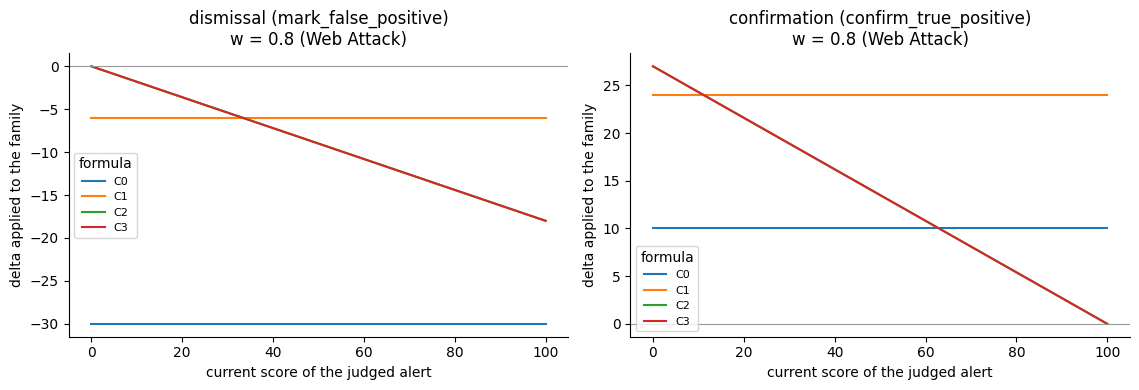

In [4]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print("matplotlib is not installed - the plot is skipped. The tables carry the evidence.")

if plt is not None:
    scores = list(range(0, 101))
    weight = 0.80   # a Web Attack: severity 8.0
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
    panels = [("mark_false_positive", "dismissal (mark_false_positive)"),
              ("confirm_true_positive", "confirmation (confirm_true_positive)")]
    for ax, (category, title) in zip(axes, panels):
        for formula in FORMULAS:
            ax.plot(scores, [verdict_delta(RankingParams(formula=formula), category, s, weight)
                             for s in scores], label=formula)
        ax.axhline(0, color="#999999", linewidth=0.8)
        ax.set_title(f"{title}\nw = {weight} (Web Attack)")
        ax.set_xlabel("current score of the judged alert")
        ax.set_ylabel("delta applied to the family")
        ax.legend(title="formula", fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

**The Elo property.** On the right-hand panel, **C2 and C3 confirmations of a high score add almost
nothing**: as the score approaches 100 the expected result approaches 1, so `S - E` approaches 0,
and at exactly 100 the step is zero. On the left-hand panel the same formula gives a dismissal of a
high score a **large** step, because dismissing something rated near-certain is the biggest
surprise available. That asymmetry is deliberate in Elo and it is the reason the experiment is worth
running: an analyst's mistake *is* a surprise, and a formula that trusts surprises will act
strongly on one.

**C1 takes the opposite view.** Its dismissal step `-K(1 - w)` is scaled only by the attack type, so
it is *smallest* for the most severe attacks - the system is reluctant to drop a botnet or
infiltration family - and it does not care how confident the system already was. **C0 is flat**:
+10, -30, +15, -15 regardless of score or type. Section 7 tests whether these attitudes matter
under analyst error - and finds that, on this data, something else decided the result (F2).

---
## 3. Method

The method file is written by the experiment itself into the run folder, so what follows is the
run's own account of what it did, not a description written afterwards.

In [5]:
from IPython.display import Markdown, display

display(Markdown(method_md))

# Ranking selection experiment — method

Design: `docs/ranking-and-escalation-design.md` §6. Code: `packages/detection/ranking/`.

1. **Data.** All 5,000 demo flows, fused by the production engine (S5 rules + S6 fusion), ordered by
   timestamp. First half = calibration (the past); second half = future (never shown to the analyst).
2. **Families.** Predicted class + destination port + protocol + matched rule; unflagged flows add
   the destination IP. A verdict updates its family; future members inherit the family's state.
3. **Simulated Tier 1 analyst.** 10 rounds; each round reviews the top 25 unreviewed
   calibration alerts plus 5 randomly sampled unflagged ones (QA sampling). Verdict =
   ground truth, flipped with probability 0 %, 5 % or 15 % (analyst error).
4. **Arms.** Formulas C0-C3 x movement M1/M2 x guardrails on/off x error rate x 3 seeds.
   Guardrails off removes the caps, floors, I3 and tier-loss protection; the 0-100 range remains.
5. **Metrics, future half only**: precision in the top 50/100/200; mean attack position (0-1, lower
   is better); last attack position; benign alerts in the top 100; Critical floor violations;
   true attacks demoted; Tier 2 load and precision; class changes during calibration.
6. **Selection (sel-2).** Among guarded arms: safety first (no floor violation at any
   error rate; no attack demoted at 0 % error); then fewest true attacks demoted under analyst error
   (5 % + 15 %); then highest Tier 2 precision at 5 %; then lowest mean attack position at 5 %; then
   fewest class changes; then the simpler formula and movement.
   *sel-1* (run 20260911T111249Z) ranked on precision in the top 100 first; the control already
   scores 1.0 there, so it could not discriminate. sel-2 was written after seeing that run.


In [6]:
sizes = pd.Series({
    "flows (demo sample, timestamp order)": config["flows"],
    "calibration half (the analyst sees these)": config["calibration"],
    "future half (scored, never shown)": config["future"],
    "attacks in calibration": config["calibration_attacks"],
    "attacks in future": config["future_attacks"],
    "seeds": config["seeds"],
    "error rates": config["error_rates"],
    "rounds": config["rounds"],
    "batch per round": config["batch"],
    "QA sample per round": config["qa_sample"],
    "severity chart version": config["severity_chart"],
    "selection rule": config["selection_rule"],
})
print(sizes.to_string())
print(f"\nrun {LATEST}  started {config['started']}  commit {config['commit']}")
print(f"severity chart file: {config['severity_chart_file']}")

flows (demo sample, timestamp order)                                   5000
calibration half (the analyst sees these)                              2500
future half (scored, never shown)                                      2500
attacks in calibration                                                  600
attacks in future                                                       400
seeds                                        [20260911, 20260912, 20260913]
error rates                                               [0.0, 0.05, 0.15]
rounds                                                                   10
batch per round                                                          25
QA sample per round                                                       5
severity chart version                                                sev-1
selection rule                                                        sel-2

run 20260911T111625Z  started 2026-09-11T11:16:25.519168Z  commit 0f91527
severity char

---
## 4. Run history

`history.jsonl` holds one line per run. The table shows every line, so this notebook keeps working
when further runs are appended; sections 5 onwards analyse the **latest** run only.

In [7]:
hist_rows = []
for entry in history:
    winner = entry["winner"]
    hist_rows.append({
        "run_id": entry["run_id"],
        "commit": entry.get("commit", ""),
        "severity_chart": entry.get("severity_chart", ""),
        "selection_rule": entry.get("selection_rule", "sel-1"),
        "winner": f'{winner["formula"]} + {winner["movement"]}',
        "safe": winner.get("safe"),
    })
history_df = pd.DataFrame(hist_rows)
print(history_df.to_string(index=False))
print(f"\nfirst run has no selection_rule field: "
      f"{'selection_rule' not in history[0]}  -> recorded as sel-1")
print(f"analysing the latest run: {LATEST}")

          run_id  commit severity_chart selection_rule  winner  safe
20260911T111249Z 0f91527          sev-1          sel-1 C1 + M2  True
20260911T111625Z 0f91527          sev-1          sel-2 C1 + M1  True

first run has no selection_rule field: True  -> recorded as sel-1
analysing the latest run: 20260911T111625Z


**Why there are two selection rules, and why both runs are kept.** The first run used **sel-1**,
whose first criterion was precision in the top 100. On this demo sample the no-feedback control
already scores 1.0 there and so does every arm, so the first criterion could not separate anything;
the rule fell through to its class-change tie-break and named a winner on a metric that measures
churn rather than quality. That is a defect in the rule, not in the arms.

**sel-2** was written *after* seeing the first run, and ranks on metrics that actually vary: safety
first, then true attacks demoted under analyst error, then Tier 2 precision, then mean attack
position, then class changes, then simplicity. It lives in
[`experiment.py`](../packages/detection/ranking/experiment.py) with that history in its docstring.

Both runs are kept on purpose. Replacing the first run's record would hide the fact that a selection
rule was written after its own first result - which is a real methodological weakness and is only
honest if it is visible. The winner of run 1 is *not* adopted.

---
## 5. Results of the latest run

The **control** is the same future queue with no analyst feedback at all: the floor that any
feedback arm has to beat, or at least not damage.

In [8]:
control = pd.Series(results["control"])
print(f"control - no feedback, future half of run {LATEST}:\n")
print(control.to_string())

agg = pd.DataFrame(results["aggregates"])
agg["arm"] = agg.formula + "+" + agg.movement
guarded = agg[agg.guardrails]
print(f"\naggregated arms: {len(agg)}  (guardrails on: {len(guarded)}, "
      f"guardrails off: {len(agg) - len(guarded)})")
print("each aggregate is the mean over seeds:", sorted(agg.seeds.unique()))

control - no feedback, future half of run 20260911T111625Z:

precision_at_50            1.0000
precision_at_100           1.0000
precision_at_200           1.0000
mean_attack_position       0.0829
last_attack_position    1787.0000
benign_in_top_100          0.0000
floor_violations           0.0000
attacks_demoted            0.0000
tier2_load               243.0000
tier2_precision            1.0000

aggregated arms: 48  (guardrails on: 24, guardrails off: 24)
each aggregate is the mean over seeds: [np.int64(3)]


In [9]:
for metric in ["attacks_demoted", "tier2_precision", "tier2_load", "mean_attack_position"]:
    pivot = guarded.pivot_table(index="arm", columns="error_rate", values=metric, aggfunc="mean")
    print(f"--- {metric}  (guardrails on, rows = formula+movement, columns = analyst error rate) ---")
    print(pivot.to_string())
    print()

--- attacks_demoted  (guardrails on, rows = formula+movement, columns = analyst error rate) ---
error_rate  0.00     0.05  0.15
arm                            
C0+M1        0.0  19.6667  59.0
C0+M2        0.0  19.6667  59.0
C1+M1        0.0   0.0000   0.0
C1+M2        0.0   0.0000   0.0
C2+M1        0.0  59.0000  59.0
C2+M2        0.0  59.0000  59.0
C3+M1        0.0  59.0000  59.0
C3+M2        0.0  59.0000  59.0

--- tier2_precision  (guardrails on, rows = formula+movement, columns = analyst error rate) ---
error_rate  0.00    0.05    0.15
arm                             
C0+M1        1.0  1.0000  1.0000
C0+M2        1.0  0.7405  0.4490
C1+M1        1.0  1.0000  1.0000
C1+M2        1.0  0.7418  0.4782
C2+M1        1.0  1.0000  1.0000
C2+M2        1.0  0.7253  0.4468
C3+M1        1.0  1.0000  1.0000
C3+M2        1.0  0.7253  0.4468

--- tier2_load  (guardrails on, rows = formula+movement, columns = analyst error rate) ---
error_rate   0.00      0.05      0.15
arm                        

In [10]:
rate = 0.15
sub = agg[agg.error_rate == rate]
on = sub[sub.guardrails].set_index("arm")
off = sub[~sub.guardrails].set_index("arm")
compare = pd.DataFrame({
    "ON  floor_violations": on.floor_violations,
    "OFF floor_violations": off.floor_violations,
    "ON  attacks_demoted": on.attacks_demoted,
    "OFF attacks_demoted": off.attacks_demoted,
})
print(f"Guardrails on versus off at analyst error rate {rate}:\n")
print(compare.to_string())

Guardrails on versus off at analyst error rate 0.15:

       ON  floor_violations  OFF floor_violations  ON  attacks_demoted  OFF attacks_demoted
arm                                                                                        
C0+M1                     0                     1                 59.0              19.6667
C0+M2                     0                     1                 59.0              19.6667
C1+M1                     0                     0                  0.0               0.0000
C1+M2                     0                     0                  0.0               0.0000
C2+M1                     0                     0                 59.0              59.0000
C2+M2                     0                     0                 59.0              59.0000
C3+M1                     0                     0                 59.0              59.0000
C3+M2                     0                     0                 59.0              59.0000


In [11]:
selection_df = pd.DataFrame(results["selection"])
selection_df.insert(0, "rank", range(1, len(selection_df) + 1))
print(f"Selection (rule {config['selection_rule']}) - ranked best first:\n")
print(selection_df.to_string(index=False))

Selection (rule sel-2) - ranked best first:

 rank formula movement  safe  attacks_demoted_under_error  tier2_precision  tier2_load  mean_attack_position  precision_at_100  class_changes
    1      C1       M1  True                       0.0000           1.0000    243.0000                0.0828               1.0        24.6667
    2      C1       M2  True                       0.0000           0.7418    504.0000                0.1235               1.0        13.6667
    3      C0       M1  True                      78.6667           1.0000    223.3333                0.0828               1.0        25.0000
    4      C0       M2  True                      78.6667           0.7405    484.3333                0.1236               1.0        14.0000
    5      C2       M1  True                     118.0000           1.0000    184.0000                0.0845               1.0        26.6667
    6      C3       M1  True                     118.0000           1.0000    184.0000                0

**Interpretation.** Under sel-2 every guarded arm is *safe*: no Critical alert fell below its floor at
any error rate, and no true attack was demoted when the analyst was never wrong. The arms separate once
the analyst *is* wrong - but section 7 shows that most of that separation traces to one family, not to
how each formula treats a mistake. `attacks_demoted` counts future attacks whose score fell below their
detection score, or whose queue class fell below the no-feedback class.

Read the guardrails-on/off table carefully. Only C0 *without* guardrails, at 15 % error, let a Critical
alert fall below the floor (a mean of one over three seeds); for the other formulas the guardrails made
no difference to floor violations on this data. And C0 *with* guardrails demoted more attacks at 15 %
(59) than without (about 20): the guardrails change the queue order, so the analyst reviews different
alerts. Nor did the guardrails stop the demotion that decides this run (F2) - a score cut from 100 to
82 stays above the Critical floor of 70; it only leaves the Tier 2 band.

---
## 6. Charts

The same tables as above, plotted against the analyst error rate. Each line is one guarded
formula+movement arm. If matplotlib is not installed the code cell says so and prints nothing; the
tables in section 5 carry the same evidence.

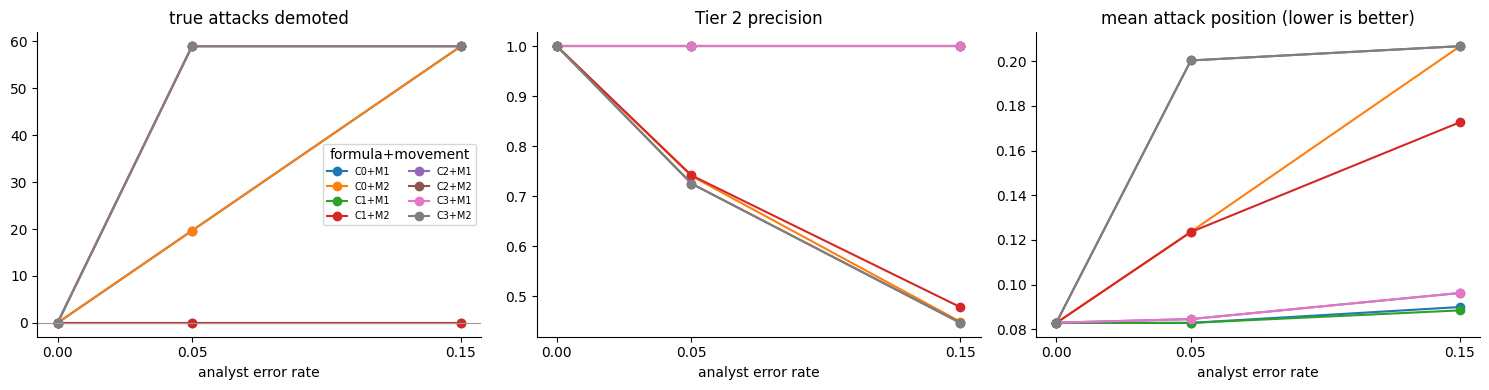

In [12]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print("matplotlib is not installed - plots skipped. See the tables in section 5.")

if plt is not None:
    metrics = [("attacks_demoted", "true attacks demoted"),
               ("tier2_precision", "Tier 2 precision"),
               ("mean_attack_position", "mean attack position (lower is better)")]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (metric, title) in zip(axes, metrics):
        for arm, block in guarded.groupby("arm"):
            block = block.sort_values("error_rate")
            ax.plot(block.error_rate, block[metric], marker="o", label=arm)
        ax.set_title(title)
        ax.set_xlabel("analyst error rate")
        ax.set_xticks(sorted(guarded.error_rate.unique()))
        ax.spines[["top", "right"]].set_visible(False)
    axes[0].axhline(0, color="#999999", linewidth=0.8)
    axes[0].legend(title="formula+movement", fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()

---
## 7. Findings

Each finding is stated, then computed from `results.json` in a code cell, then interpreted. The
interpretation never quotes a number that the code above it did not just print.

### F1 - precision in the top 100 is saturated

In [13]:
print(f"F1  top-100 saturation, run {LATEST}\n")
print(f"control (no feedback) precision_at_100: {results['control']['precision_at_100']}\n")
wide = agg.pivot_table(index="arm", columns="guardrails", values="precision_at_100", aggfunc="mean")
print("every arm, guardrails off / on:")
print(wide.to_string())
print(f"\ndistinct precision_at_100 values across all arms and the control: "
      f"{sorted(set(agg.precision_at_100) | {results['control']['precision_at_100']})}")
print(f"\nbenign alerts in the top 100 - control {results['control']['benign_in_top_100']}, "
      f"arms {sorted(set(agg.benign_in_top_100))}")

F1  top-100 saturation, run 20260911T111625Z

control (no feedback) precision_at_100: 1.0

every arm, guardrails off / on:
guardrails  False  True 
arm                     
C0+M1         1.0    1.0
C0+M2         1.0    1.0
C1+M1         1.0    1.0
C1+M2         1.0    1.0
C2+M1         1.0    1.0
C2+M2         1.0    1.0
C3+M1         1.0    1.0
C3+M2         1.0    1.0

distinct precision_at_100 values across all arms and the control: [1.0]

benign alerts in the top 100 - control 0, arms [0]


**Interpretation.** The control already puts zero benign alerts in the top 100, so `precision_at_100`
is 1.0 for the control and for **every** arm under both guardrail settings. This is not a good
result for the arms - it is the absence of a discriminating measurement. When the detector is this
clean on the demo sample, the top of the queue has no false positives, so feedback has nothing to
correct there. This is exactly why sel-1, whose first criterion was this metric, could not choose:
it saw a wall of ties and fell through to its tie-break. It is also why the metrics that were moved
forward in sel-2 are the ones that do vary - `attacks_demoted`, `tier2_precision`, and the class
changes.

### F2 - every demoted attack traces to one family, and a correct verdict caused it

In [14]:
print(f"F2  true attacks demoted, summed over the error rates > 0 (guarded arms), run {LATEST}\n")
guarded_error = guarded[guarded.error_rate > 0]
by_formula = guarded_error.groupby("formula").attacks_demoted.sum().round(2)
print("summed over analyst error rates (5 % and 15 %), both movements:")
print(by_formula.to_string())
print("\nthe same, split by movement (mean over the 3 seeds and the two error rates):")
print(guarded_error.pivot_table(index="formula", columns="movement",
                                values="attacks_demoted").round(2).to_string())
print(f"\nlowest total: {by_formula.idxmin()} with {by_formula.min()}")

F2  true attacks demoted, summed over the error rates > 0 (guarded arms), run 20260911T111625Z

summed over analyst error rates (5 % and 15 %), both movements:
formula
C0    157.33
C1      0.00
C2    236.00
C3    236.00

the same, split by movement (mean over the 3 seeds and the two error rates):
movement     M1     M2
formula               
C0        39.33  39.33
C1         0.00   0.00
C2        59.00  59.00
C3        59.00  59.00

lowest total: C1 with 0.0


In [15]:
print("\nwhy: one verdict's step, as a function of the current score\n")
weight = 0.80   # Web Attack
probe_scores = [40.0, 70.0, 95.0, 100.0]
rows = []
for score in probe_scores:
    rows.append({
        "current score": score,
        "C1 confirm": round(verdict_delta(RankingParams(formula="C1"), "confirm_true_positive",
                                          score, weight), 2),
        "C2 confirm": round(verdict_delta(RankingParams(formula="C2"), "confirm_true_positive",
                                          score, weight), 2),
        "C1 dismiss": round(verdict_delta(RankingParams(formula="C1"), "mark_false_positive",
                                          score, weight), 2),
        "C2 dismiss": round(verdict_delta(RankingParams(formula="C2"), "mark_false_positive",
                                          score, weight), 2),
    })
print(pd.DataFrame(rows).to_string(index=False))
print("\nthe same dismissal, for a mild type (Port Scan, w = 0.30) and a severe one (Infiltration,")
print("w = 0.95) at score 95 - C1's step depends on the type, C2's barely does:")
for attack, w in [("Port Scan", 0.30), ("Infiltration", 0.95)]:
    c1 = verdict_delta(RankingParams(formula="C1"), "mark_false_positive", 95.0, w)
    c2 = verdict_delta(RankingParams(formula="C2"), "mark_false_positive", 95.0, w)
    print(f"  w = {w:.2f} ({attack:<13})  C1 {c1:7.2f}   C2 {c2:7.2f}")


why: one verdict's step, as a function of the current score

 current score  C1 confirm  C2 confirm  C1 dismiss  C2 dismiss
          40.0        24.0       16.20        -6.0        -7.2
          70.0        24.0        8.10        -6.0       -12.6
          95.0        24.0        1.35        -6.0       -17.1
         100.0        24.0        0.00        -6.0       -18.0

the same dismissal, for a mild type (Port Scan, w = 0.30) and a severe one (Infiltration,
w = 0.95) at score 95 - C1's step depends on the type, C2's barely does:
  w = 0.30 (Port Scan    )  C1  -21.00   C2  -24.22
  w = 0.95 (Infiltration )  C1   -1.50   C2  -14.96


In [16]:
# Where do the demoted attacks come from? Re-run the calibration phase with the experiment's own
# code (experiment.calibrate - the function simulate() uses) and trace every demoted future attack
# to its family and to the verdicts that family received.
from collections import Counter
from packages.detection.ranking import experiment as E

demo_flows = E.load_flows(HITL / "data/processed", chart)
half = len(demo_flows) // 2
calibration, future = demo_flows[:half], demo_flows[half:]
kw = dict(rounds=config["rounds"], batch=config["batch"], qa_sample=config["qa_sample"])

# Guard: the trace means nothing unless this environment replays the recorded run exactly. The flow
# order comes from parsing timestamps, which has differed between library versions, so re-simulate
# every recorded guarded arm at 5 % error and stop if any differs.
probes = [r for r in results["runs"] if r["guardrails"] and r["error_rate"] == 0.05]
mismatched = [(r["formula"], r["movement"], r["seed"]) for r in probes
              if E.simulate(calibration, future, E.Arm(r["formula"], r["movement"], True,
                                                       r["error_rate"], r["seed"]), **kw) != r]
assert not mismatched, (f"this environment does not replay run {LATEST}: {mismatched}. "
                        f"Compare its config.json environment with this kernel's.")
print(f"{len(probes)} recorded arms replay identically in this environment\n")


def trace(formula, movement, error_rate, seed):
    families, log = E.calibrate(calibration, E.Arm(formula, movement, True, error_rate, seed), **kw)
    queue = E.rank(future, families, True)
    demoted = Counter(f.family for cls, score, f in queue if f.malicious and (
        score < f.detection_score or cls > E.baseline_class(f)))
    benign_tier2 = Counter(f.family for cls, score, f in queue if cls == 0 and not f.malicious)
    return families, log, demoted, benign_tier2


def verdicts(log, family):
    return dict(Counter((e["verdict"], "wrong" if e["wrong"] else "correct",
                         "attack" if e["malicious"] else "benign")
                        for e in log if e["family"] == family))


traces = {(formula, error_rate, seed): trace(formula, "M1", error_rate, seed)
          for formula in FORMULAS for error_rate in config["error_rates"] for seed in config["seeds"]}
rows = [{"formula": formula, "error rate": error_rate, "seed": seed, "family": family,
         "attacks demoted": n, "verdicts the family received": verdicts(log, family)}
        for (formula, error_rate, seed), (_, log, demoted, _) in traces.items()
        for family, n in demoted.items()]
print("every demoted future attack, traced to its family (movement M1, guardrails on):\n")
print(pd.DataFrame(rows).to_string(index=False) if rows else "none")
collided = sorted({row["family"] for row in rows}, key=str)
print(f"\ndistinct families holding a demoted attack: {collided}")

if collided:
    family = collided[0]
    first_seed = config["seeds"][0]
    for formula in ("C2", "C0"):
        log = traces[(formula, 0.05, first_seed)][1]
        for e in (e for e in log if e["family"] == family):
            print(f"\n{formula}, 5 % error, seed {first_seed}: round {e['round']}, {e['verdict']} on "
                  f"{e['alert_id']} - a {'true attack' if e['malicious'] else 'benign'} flow, "
                  f"{'wrong' if e['wrong'] else 'correct'} verdict; score {e.get('score')}, family "
                  f"adjustment {e.get('adjustment_before')} -> {round(e.get('adjustment_after', 0), 2)}")
    members = [f for f in future if f.family == family]
    print(f"\nfuture flows in that family: {len(members)}, true attacks among them: "
          f"{sum(f.malicious for f in members)}")
    reached = {formula: sum(any(e["family"] == family for e in traces[(formula, er, s)][1])
                            for er in config["error_rates"] for s in config["seeds"])
               for formula in FORMULAS}
    print(f"arms (of {len(config['error_rates']) * len(config['seeds'])} per formula) in which the "
          f"analyst reviewed a flow of that family: {reached}")

24 recorded arms replay identically in this environment



every demoted future attack, traced to its family (movement M1, guardrails on):

formula  error rate     seed                   family  attacks demoted                                                                       verdicts the family received
     C0        0.05 20260911 (Web Attack, 80, TCP, -)               59                                                  {('mark_false_positive', 'correct', 'benign'): 1}
     C0        0.15 20260911 (Web Attack, 80, TCP, -)               59                                                  {('mark_false_positive', 'correct', 'benign'): 1}
     C0        0.15 20260912 (Web Attack, 80, TCP, -)               59 {('confirm_true_positive', 'wrong', 'benign'): 1, ('mark_false_positive', 'correct', 'benign'): 1}
     C0        0.15 20260913 (Web Attack, 80, TCP, -)               59                                                  {('mark_false_positive', 'correct', 'benign'): 1}
     C2        0.05 20260911 (Web Attack, 80, TCP, -)               5

**Interpretation - and a correction.** The totals say C1 demotes no attacks while C0 and C2/C3 demote
dozens. An earlier draft of this record, and of the design document, explained that by the Elo form
"trusting surprises": a wrong dismissal of a near-certain alert is a large update. **The trace above
contradicts that.** Every demoted attack, in every seed and error rate, sits in one family -
`('Web Attack', 80, 'TCP', '-')` - and the verdict that demoted it was **correct**: the analyst
rightly dismissed one *benign* flow the model had scored 99.89 as a Web Attack. The family key put
that false positive in the same family as 59 true Web Attacks in the future half, so the correct
dismissal cut their scores from 100 to 82 under C2 - below the Tier 2 threshold of 90. The Critical
floor of 70 did not bite, so no guardrail fired.

The formulas differ not through the size of their step but through **which alerts the analyst
reached**. C1's large confirmation steps reorder the queue so that the benign flow is never reviewed
in ten rounds; C2 reaches it in every seed, C0 in some. (Had C1 reached it, its step of -6 would have
left those attacks at 94 - still in Tier 2, but still counted as demoted by this metric.) At 0 % error
no formula reaches it, which is why the effect appears only "under analyst error": mistakes reshuffle
the queue deeper. **C1's zero is coverage, not robustness**, and this experiment gives no evidence
that one formula handles analyst error better than another. The step tables earlier in this section
remain correct arithmetic; they are just not what separated the arms.

### F3 - M2 floods Tier 2 under analyst error

In [17]:
rate = 0.05
print(f"F3  Tier 2 at analyst error rate {rate}, run {LATEST}\n")
rows = []
for movement in MOVEMENTS:
    block = guarded[(guarded.error_rate == rate) & (guarded.movement == movement)]
    for _, row in block.sort_values("formula").iterrows():
        rows.append({"movement rule": movement, "formula": row.formula,
                     "tier2_load": round(row.tier2_load, 1),
                     "tier2_precision": round(row.tier2_precision, 4)})
tier2_df = pd.DataFrame(rows)
print(tier2_df.to_string(index=False))
print(f"\ncontrol (no feedback): load {results['control']['tier2_load']}, "
      f"precision {results['control']['tier2_precision']}")
print("\nmovement rule, averaged over formulas:")
print(guarded[guarded.error_rate == rate].groupby("movement")[
    ["tier2_load", "tier2_precision"]].mean().round(4).to_string())

F3  Tier 2 at analyst error rate 0.05, run 20260911T111625Z

movement rule formula  tier2_load  tier2_precision
           M1      C0       223.3           1.0000
           M1      C1       243.0           1.0000
           M1      C2       184.0           1.0000
           M1      C3       184.0           1.0000
           M2      C0       484.3           0.7405
           M2      C1       504.0           0.7418
           M2      C2       471.3           0.7253
           M2      C3       471.3           0.7253

control (no feedback): load 243, precision 1.0

movement rule, averaged over formulas:
          tier2_load  tier2_precision
movement                             
M1          208.5833           1.0000
M2          482.7500           0.7332


In [18]:
print("the benign alerts M2 put in the Tier 2 band, traced to their families "
      "(C1 + M2, guardrails on, 5 % error):\n")
for seed in config["seeds"]:
    _, log, _, benign_tier2 = trace("C1", "M2", 0.05, seed)
    print(f"seed {seed}: {sum(benign_tier2.values())} benign alerts in Tier 2")
    for family, n in benign_tier2.most_common(3):
        print(f"   {n:4} in {family}: verdicts {verdicts(log, family)}")

the benign alerts M2 put in the Tier 2 band, traced to their families (C1 + M2, guardrails on, 5 % error):

seed 20260911: 3 benign alerts in Tier 2
      1 in ('Benign', 3389, 'TCP', '-', '172.31.67.58'): verdicts {('confirm_true_positive', 'wrong', 'benign'): 1}
      1 in ('Benign', 3389, 'TCP', '-', '172.31.66.118'): verdicts {('confirm_true_positive', 'wrong', 'benign'): 1}
      1 in ('Benign', 3389, 'TCP', '-', '172.31.68.28'): verdicts {('confirm_true_positive', 'wrong', 'benign'): 1}
seed 20260912: 0 benign alerts in Tier 2
seed 20260913: 780 benign alerts in Tier 2
    779 in ('Benign', 53, 'UDP', '-', '172.31.0.2'): verdicts {('mark_false_positive', 'correct', 'benign'): 13, ('confirm_true_positive', 'wrong', 'benign'): 1}
      1 in ('Benign', 3389, 'TCP', '-', '172.31.65.18'): verdicts {('confirm_true_positive', 'wrong', 'benign'): 1}


**Interpretation.** Under M1 the Tier 2 list for C1 is identical to the control's - 243 alerts, all
attacks. The *smaller* M1 lists under C0 and C2/C3 are not a gain: 243 - 184 = 59, exactly the Web
Attacks that F2 traced out of the Tier 2 band.

M2 is different in kind, and the trace above shows the mechanism. Under M2 a single confirming verdict
sends the family straight to the top class **whatever the family's history**. In one seed, one wrong
confirmation of a benign DNS flow outweighed thirteen correct dismissals of the same family and lifted
all 779 of its future flows into the Tier 2 band; another seed added 3 benign alerts, the third none.
The 5 % mean (load about 504, precision about 0.74) is that rare, severe failure averaged over seeds -
exactly the failure a Tier 2 list cannot afford (Q25). M1 moves one class per confirmation and lets the
demotion shield push back, so no single verdict can do this. **This finding survives the correction in
F2: M1 over M2 is supported.**

### F4 - C3 and C2 are identical on this data

In [19]:
metric_cols = ["precision_at_50", "precision_at_100", "precision_at_200", "mean_attack_position",
               "last_attack_position", "benign_in_top_100", "floor_violations", "attacks_demoted",
               "tier2_load", "tier2_precision", "verdicts", "wrong_verdicts", "class_changes",
               "future_flows_in_learned_families", "seeds"]
key = ["movement", "guardrails", "error_rate"]

c2 = agg[agg.formula == "C2"].set_index(key).sort_index()[metric_cols]
c3 = agg[agg.formula == "C3"].set_index(key).sort_index()[metric_cols]
same = c2.equals(c3)
print(f"F4  C2 versus C3, run {LATEST}\n")
print(f"aggregates compared: {len(c2)} (movement x guardrails x error rate)\n")
print(f"identical: {same}")
print(f"largest absolute difference in any metric: {float((c2 - c3).abs().to_numpy().max())}")
print("\nC2 aggregate for reference:")
print(c2.to_string())

F4  C2 versus C3, run 20260911T111625Z

aggregates compared: 12 (movement x guardrails x error rate)

identical: True
largest absolute difference in any metric: 0.0

C2 aggregate for reference:
                                precision_at_50  precision_at_100  precision_at_200  mean_attack_position  last_attack_position  benign_in_top_100  floor_violations  attacks_demoted  tier2_load  tier2_precision  verdicts  wrong_verdicts  class_changes  future_flows_in_learned_families  seeds
movement guardrails error_rate                                                                                                                                                                                                                                                                      
M1       False      0.00                    1.0               1.0            1.0000                0.0829             1787.0000                  0                 0              0.0    243.0000           1.0000       300

In [20]:
print("\nC3's damping is real, not a no-op: its step as a fraction of C2's, for a family with n")
print("prior verdicts (computed from verdict_delta, not reimplemented):\n")
for n in (0, 1, 3, 10, 30, 100):
    base = verdict_delta(RankingParams(formula="C2"), "confirm_true_positive", 20.0, 0.5, n)
    damped = verdict_delta(RankingParams(formula="C3"), "confirm_true_positive", 20.0, 0.5, n)
    print(f"  n = {n:>3} verdicts:  C2 {base:6.3f}   C3 {damped:6.3f}   u = {damped / base:.3f}")
n_floor = 3 * (1 / 0.4 ** 2 - 1)
print(f"\nu reaches its 0.4 floor at n = 3(1/0.4^2 - 1) = {n_floor:.2f}: from the 16th prior verdict on.")
print(f"verdicts per arm (mean over seeds): {agg.verdicts.mean():.1f}  "
      f"class changes per arm (mean): {agg.class_changes.mean():.1f}")


C3's damping is real, not a no-op: its step as a fraction of C2's, for a family with n
prior verdicts (computed from verdict_delta, not reimplemented):

  n =   0 verdicts:  C2 18.000   C3 18.000   u = 1.000
  n =   1 verdicts:  C2 18.000   C3 15.588   u = 0.866
  n =   3 verdicts:  C2 18.000   C3 12.728   u = 0.707
  n =  10 verdicts:  C2 18.000   C3  8.647   u = 0.480
  n =  30 verdicts:  C2 18.000   C3  7.200   u = 0.400
  n = 100 verdicts:  C2 18.000   C3  7.200   u = 0.400

u reaches its 0.4 floor at n = 3(1/0.4^2 - 1) = 15.75: from the 16th prior verdict on.
verdicts per arm (mean over seeds): 300.0  class changes per arm (mean): 22.5


In [21]:
# Why C2 and C3 agree: the families whose learned adjustment differs between the two formulas,
# re-run with the experiment's own calibration code.
seed = config["seeds"][0]
rows = []
for movement in MOVEMENTS:
    for error_rate in config["error_rates"]:
        c2 = E.calibrate(calibration, E.Arm("C2", movement, True, error_rate, seed), **kw)[0]
        c3 = E.calibrate(calibration, E.Arm("C3", movement, True, error_rate, seed), **kw)[0]
        keys = set(c2) | set(c3)
        differing = [k for k in keys if round(c2[k].adjustment, 6) != round(c3[k].adjustment, 6)]
        members = [f for f in future if f.family in differing]
        rows.append({"movement": movement, "error rate": error_rate, "families learned": len(keys),
                     "adjustment differs": len(differing),
                     "class differs": sum(c2[k].class_offset != c3[k].class_offset for k in keys),
                     "future flows in those families": len(members),
                     "of which attacks": sum(f.malicious for f in members)})
print(f"families where C3's learned adjustment differs from C2's (seed {seed}):\n")
print(pd.DataFrame(rows).to_string(index=False))

families where C3's learned adjustment differs from C2's (seed 20260911):

movement  error rate  families learned  adjustment differs  class differs  future flows in those families  of which attacks
      M1        0.00                32                   0              0                               0                 0
      M1        0.05                36                   5              0                             860                 0
      M1        0.15                36                   3              0                             779                 0
      M2        0.00                32                   0              0                               0                 0
      M2        0.05                36                   5              0                             860                 0
      M2        0.15                36                   3              0                             779                 0


**Interpretation.** The aggregates for C3 and C2 are **identical** in every metric, under both
movement rules, both guardrail settings and all three error rates. The damping itself is real - the
cell above shows C3's step falling to 0.4 of C2's from a family's 16th prior verdict - so identical
results need an explanation, and the table gives it: where the two formulas' adjustments differ at
all, the differing families hold **no future attack**, and the benign flows they do hold score far
below the top of the queue under either formula. C3 changes scores where the metrics are not looking.

There is also a structural reason the damping rarely matters here: C3 differs from C2 only after a
family's first verdict, and the one family that decided this run (F2) received exactly one. The
correct statement is that **this experiment could not distinguish C3 from C2** - not that the damping
failed.

### F5 - feedback reaches future traffic, but this sample leaves little ordering to gain

In [22]:
print(f"F5  reach and headroom, run {LATEST}\n")
future_n = config["future"]
winner = results["selection"][0]
winner_rows = guarded[(guarded.formula == winner["formula"])
                      & (guarded.movement == winner["movement"])]

print(f"future flows scored: {future_n}")
print(f"\nfuture flows belonging to a family the analyst updated during calibration")
print("(share of the future half), by formula and movement:\n")
reach = guarded.pivot_table(index="formula", columns="movement",
                            values="future_flows_in_learned_families").round(1)
print(reach.to_string())
print(f"\n  as a share of the future half: "
      f"{float(reach.to_numpy().min() / future_n):.1%} to "
      f"{float(reach.to_numpy().max() / future_n):.1%}")

print(f"\nmean attack position (0-1, lower is better):")
print(f"  control (no feedback) : {results['control']['mean_attack_position']}")
print(f"  selected arm {winner['formula']}+{winner['movement']}   : "
      f"{float(winner_rows[winner_rows.error_rate == 0.05].mean_attack_position.iloc[0])}")
print(f"  every guarded arm     : "
      f"{sorted(set(guarded.mean_attack_position.round(4)))}")

F5  reach and headroom, run 20260911T111625Z

future flows scored: 2500

future flows belonging to a family the analyst updated during calibration
(share of the future half), by formula and movement:

movement     M1     M2
formula               
C0        920.4  906.4
C1        894.2  880.2
C2        948.7  948.7
C3        948.7  948.7

  as a share of the future half: 35.2% to 37.9%

mean attack position (0-1, lower is better):
  control (no feedback) : 0.0829
  selected arm C1+M1   : 0.0828
  every guarded arm     : [0.0828, 0.0829, 0.0845, 0.0884, 0.0899, 0.0962, 0.1235, 0.1236, 0.1727, 0.2004, 0.2067, 0.2068]


**Interpretation.** Feedback does reach future traffic: over a third of the future half belongs to
families the analyst updated during calibration, so the mechanism is connecting a calibration
verdict to alerts the analyst never saw. That is the mechanism the project's goal depends on, and it is in place. F2 shows the other side of
the same reach: one verdict's harm travels just as far.

What the sample does not offer is an **efficiency** gain. The detectors already rank nearly every
attack at the top: the control's mean attack position is about 0.08 on a 0-1 scale and the selected
arm's is the same to within a ten-thousandth. There is essentially nowhere for feedback to move
attacks up to. F1 says the same thing from the other side - the top 100 is already all attacks.

So the experiment measures the **harm** analyst error does, and it measures that clearly (F2, F3),
but it cannot show a benefit, because the demo data has no disorder for the feedback to remove. The
efficiency claim is therefore **not established**, and section 9 says what would test it.

---
## 8. Decision

In [23]:
top = results["selection"][0]
print(f"selection[0] from run {LATEST} (rule {config['selection_rule']}):\n")
for name, value in top.items():
    print(f"  {name:<34} {value}")
print("\nthe full ranked list is in section 5.")
print(f"\nselected: {top['formula']} + {top['movement']}   "
      f"(safety passed: {top['safe']})")

selection[0] from run 20260911T111625Z (rule sel-2):

  formula                            C1
  movement                           M1
  safe                               True
  attacks_demoted_under_error        0
  tier2_precision                    1.0
  tier2_load                         243
  mean_attack_position               0.0828
  precision_at_100                   1.0
  class_changes                      24.6667

the full ranked list is in section 5.

selected: C1 + M1   (safety passed: True)


**Decision Q29, revised after the F2 trace.**

- **Movement rule: M1** (one class per confirmation, demotion shield of two dismissals). Supported by
  F3 and unaffected by the correction: M2 lets one confirmation override any history, and in one seed
  a single wrong confirmation put 779 benign flows into the Tier 2 band. Q25 requires the demo to show
  a Tier 2 list worth acting on.
- **Formula: not selected.** sel-2 names C1 + M1 (printed above) because C1 demoted no attacks. F2
  shows that this is not a property of C1: every demotion in the run comes from one family collision
  triggered by a *correct* verdict, and C1 avoided it only because its queue order never reached the
  colliding flow. The experiment does not separate the four formulas on how they handle analyst error.
- **What the trace does establish is a requirement for S7b:** a single verdict must not move a whole
  family. The collaborator's adopted gate (at least 3 learning verdicts, at least 0.67 agreement) and a
  family key fine enough to keep an ML false positive apart from the attacks it resembles come before
  the formula can be chosen.

The run records are kept as they are: `history.jsonl` shows what each selection rule named, and this
section shows why the formula half was withdrawn. Q28 - the severity chart as a versioned, editable
file - is unaffected. Both are recorded in [`docs/HANDOVER.md`](../docs/HANDOVER.md).

---
## 9. Limits and next experiment

**The demo sample is easy.** The 8-class detector ranks almost every attack at the top of the queue
on this data (F1, F5). Each attack class in this testbed is a near-constant fingerprint - a property
of the testbed recorded in the design document (section 6), not a real-world capability claim. With
no false positives near the top of the queue, feedback has nothing to correct, so the efficiency
benefit of the ranking cannot be measured here.

**The analyst is simulated.** Verdicts come from ground truth with a flip probability, not from a
person. Real analysts are wrong in correlated, structured ways. This experiment can say how the
formulas respond to *random* error; it cannot say how they respond to a real analyst's error.

**Families are a proxy, and F2 shows how much that matters.** A family here is predicted class +
destination port + protocol + matched rule (+ destination IP for unflagged flows). That key put one
benign ML false positive in the same family as 59 true Web Attacks. S7b will port the collaborator's
weighted similarity engine (`stage-5/core/similarity-engine.js`), which groups alerts differently.

**Learning starts at the first verdict.** The collaborator's adopted configuration
(`stage-5/config/adaptation-config.json`, `aggregation`) applies a similar-alert adjustment only after
at least 3 learning verdicts with at least 0.67 agreement. The experiment had no such gate, which is
how a single verdict moved a 59-attack family (F2) and a 779-flow benign family (F3).

**Three seeds.** Every aggregate is a mean over three seeds - enough to see large differences, not
enough for a confidence statement. F3 shows why a mean can mislead: M2's Tier 2 damage is one severe
seed averaged with two mild ones.

**Next experiments, in order.**
1. Add the agreement gate and a finer family key; rerun all arms; only then choose the formula.
2. A stress scenario with a weaker or drifting detector - one that puts real false positives near
   the top of the queue - so the claim "feedback reorders future alerts usefully" becomes testable.
3. The run on the 250,655-flow training sample planned in the design document, for larger families
   and a real test of C3's damping (F4).